In [66]:
import numpy as np
import pandas as pd
import simpy
import simpy as sp

In [67]:
# class Simulation:
#     def __init__(self,order_cutoff,order_target):
#         self.inventory = order_target
#         self.clock=0.0
#         self.num_ordered = 0
#         self.order_cutoff = order_cutoff
#         self.order_target = order_target
#         self.t_customer=self.generate_interarrival_time()
#         self.t_delivery=float("inf")
#         self.revenue=0
#         self.cost_orders=0
#         self.cost_holdings=0
#
#     def advance_time(self):
#        t_event=min(self.t_customer,self.t_delivery)
#        self.cost_holdings+=self.inventory*2*(t_event-self.clock)
#        self.clock=t_event
#        if self.t_delivery <= self.t_customer:
#            self.handle_delivery_event()
#        else:
#            self.handle_customer_event()
#     def handle_customer_event(self):
#         demand = self.generate_demand()
#         if self.inventory >= demand:
#             self.revenue+=100*demand
#             self.inventory-=demand
#         else:
#             self.revenue+=100*self.inventory
#             self.inventory=0
#         if self.inventory < self.order_cutoff and self.num_ordered ==0:
#             self.num_ordered = self.order_target - self.inventory
#             self.cost_orders += self.num_ordered*50
#             self.t_delivery = self.clock + 2
#
#         self.t_customer= self.clock + self.generate_interarrival_time()
#
#     def handle_delivery_event(self):
#         self.inventory+=self.num_ordered
#         self.num_ordered=0
#         self.t_delivery=float("inf")
#     def generate_interarrival_time(self):
#         return np.random.exponential(1/5)
#     def generate_demand(self):
#         return np.random.randint(1,5)

In [68]:
def warhouse_run(env,order_cutoff,order_target):
    global inventory,balance,num_ordered

    inventory = order_target
    balance=0.0
    num_ordered = 0

    while True:
        interarrival_time = generate_interarrival_time()
        yield env.timeout(interarrival_time)
        balance-= inventory*2*interarrival_time
        demand = generate_demand()
        if demand < inventory :
            balance += 100 * demand
            inventory-=demand
            print("{:.2f} sold {}".format(env.now,demand))
        else:
            balance += 100 * inventory
            inventory=0
            print("{:.2f} sold {} (out of stock)".format(env.now,inventory))

        if inventory < order_cutoff and num_ordered==0:
            env.process(handle_order(env,order_target))

def handle_order(env,order_target):
    global inventory,balance,num_ordered

    num_ordered = order_target - inventory
    print("{:.2f} place order for {} ".format(env.now,num_ordered))
    balance -= 50*num_ordered
    yield env.timeout(2)
    inventory+=num_ordered
    num_ordered=0
    print("{:.2f} order received, {} in inventory".format(env.now,inventory))



def generate_interarrival_time():
    return np.random.exponential(1/5)

def generate_demand():
    return np.random.randint(1,5)

obs_time=[]
inventory_level = []

def observe(env):
    global inventory
    while True:
        obs_time.append(env.now)
        inventory_level.append(inventory)
        yield env.timeout(0.1)

In [ ]:
np.random.seed(15)
env = simpy.Environment()
env.process(warhouse_run(env,5,30))
env.process(observe(env))
env.run(until=5)

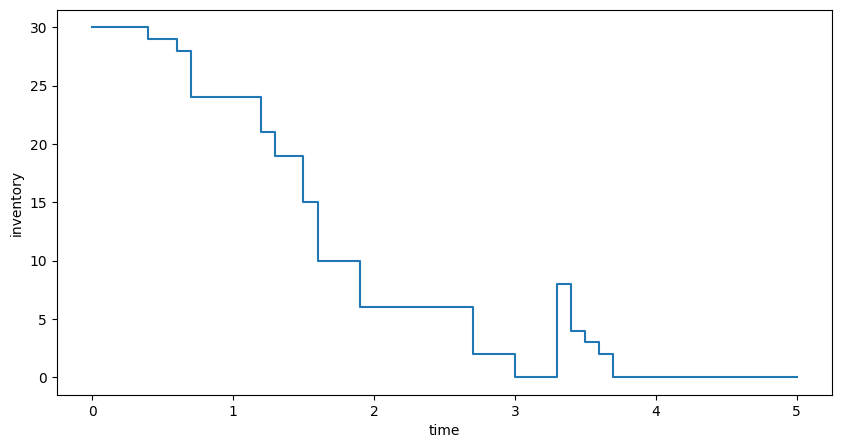

In [65]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.step(obs_time,inventory_level,where='post')
plt.xlabel('time')
plt.ylabel('inventory')
plt.show()
